<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula04b%20-%20Extreme%20Learning%20Machine%20-%20ELM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

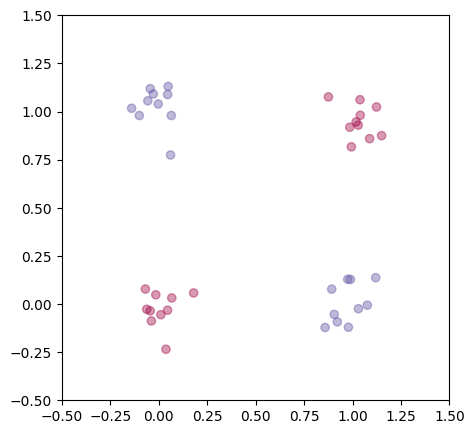

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, alpha=0.4, cmap=plt.cm.Spectral)
  plt.xlim(-0.5,1.5)
  plt.ylim(-0.5,1.5)

def plotHyperplan(vector, intercept=0):
  xs = np.array([-0.5,1.5])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, '-')

def makeLogicalDataset(n=40, func=lambda a, b: bool(a) != bool(b)):
  X, y = make_blobs(n_samples=n,
                    centers=[[0,0],[1,0],[1,1],[0,1]],
                    cluster_std=0.1)
  y = np.array([func(a>0.5, b>0.5) for a, b, in zip(X[:,0], X[:,1])], dtype=int) * 2 - 1
  return X, y

X, y = makeLogicalDataset()
plotDataset(X, y)
plt.show()

In [82]:
def defineAxes(X):
  offset = 0.5
  min1, max1 = X[:,0].min()-offset, X[:,0].max()+offset
  min2, max2 = X[:,1].min()-offset, X[:,1].max()+offset
  return [min1, max1, min2, max2]

def plotPredictions(model, X):
  axes = defineAxes(X)
  x0s = np.linspace(axes[0], axes[1], 100)
  x1s = np.linspace(axes[2], axes[3], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)


In [91]:
def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  return (a>=0)*2-1

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class ExtremeLearningMachine(BaseEstimator, ClassifierMixin):
  def __init__(self, n_hidden=20, activ_func=np.tanh):
    self.n_hidden = n_hidden
    self.activ_func = activ_func

  def fit(self, X, y):
    Xb = include_bias(X)
    self.ihw = np.random.uniform(-1, 1, size=(Xb.shape[1], self.n_hidden))
    self.pH = Xb @ self.ihw
    self.H = self.activ_func(self.pH)
    self.Hb = include_bias(self.H)
    self.how = np.linalg.pinv(self.Hb) @ y
    return self

  def predict(self, X):
    Xb = include_bias(X)
    self.pH = Xb @ self.ihw
    self.H = self.activ_func(self.pH)
    self.Hb = include_bias(self.H)
    logits = self.Hb @ self.how
    ypred = sign(logits)
    return ypred

model = ExtremeLearningMachine()
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(model.how)

Accuracy: 1.0
[ -4823.76230405   -196.76825251   -261.99677556   -295.6027874
  -1088.27502998    641.64902573   -325.56200127    403.91049836
   -324.41291719   7733.28905834     36.5922786     406.57550788
  -3518.37305604  -2906.98637443     43.09366175    332.32073232
   1455.83768964  -2495.55504668   -154.76752635    451.76223045
 -12632.9496413 ]


In [96]:
from scipy.special import expit

model = ExtremeLearningMachine(activ_func=expit)
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(model.how)

Accuracy: 1.0
[ 466513.54636256   -4866.23757117  -92105.44304385 -387749.67058781
  218129.97444436  -30787.3807045    77974.2467357   111352.82349073
   13294.78084908   35372.2071155   -28912.84150116  -21637.00078293
   29025.66461835 -389362.05539821 -407644.22144208   -4668.98182467
   18559.56948181   25170.58399102    1048.37727733  103335.06881193
  -57344.13279611]


In [103]:
model = ExtremeLearningMachine(activ_func=sign)
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(model.how)

Accuracy: 1.0
[-2.42861287e-16 -1.59594560e-16  1.94289029e-16  0.00000000e+00
  3.33333333e-01 -6.93889390e-18 -5.00000000e-01 -5.55111512e-16
 -1.80411242e-16  6.93889390e-17  2.08166817e-16 -5.00000000e-01
  2.35922393e-16 -2.22044605e-16 -3.33333333e-01 -1.66533454e-16
  1.66533454e-16  1.66533454e-16 -3.33333333e-01  3.33066907e-16
 -1.00000000e+00]


Accuracy: 1.0
[-30.3196066    3.29803653  76.23705346  -3.10831276  32.68311126
  13.51383608]


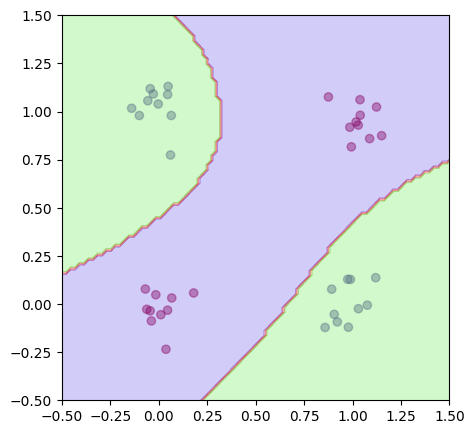

In [137]:
model = ExtremeLearningMachine(n_hidden=5)
model.fit(X, y)
ypred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(model.how)
plotDataset(X, y)
plotPredictions(model, X)
plt.show()